# MSD Postselection Experiment

This notebook wires together the experimental `PostSelectionExperiment`
scaffold for three cases:

- distilled MSD with an MLD table decoder,
- distilled MSD with an MLE decoder,
- injected-state tomography with a degenerate no-ancilla MLD table decoder.

The default shot counts are intentionally small so the notebook can run as a
smoke test. Increase the constants below to approach the paper-scale curves.



In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
from bloqade.analysis.tomography import DEFAULT_TARGET_BLOCH
from bloqade.lanes import GeminiLogicalSimulator
from bloqade.gemini.decoding.workflow import plot_decoder_curves

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "demo":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from demo.msd_utils.application.experiments import (
    PostSelectionExperiment,
    empty_logical_circuit,
    magic_state_dist_steane,
    single_qubit_state_tomography,
)
from demo.msd_utils.application.experiments_helpers import (
    construct_confidence_decoders_mld,
    construct_confidence_decoders_mle,
    construct_full_factory_decoders_mld,
    construct_full_factory_decoders_mle,
)



## Configuration



In [ ]:
EVAL_SHOTS = 1_000_000
MLD_TRAIN_SHOTS = 10_000_000
MLD_RANK_TRAIN_SHOTS = 10_000_000
MLD_BATCH_SIZE = None
SIM_TYPE = "clifft"

BINARY_PRECISION = 4
THRESHOLD_POINTS = 24
MIN_ACCEPTED_PER_BASIS = 50
SPECIAL_KERNEL_STRATEGY = "prefix_prepare"

DISTILLED_SIGN_VECTOR = (1.0, -1.0, 1.0)
INJECTED_SIGN_VECTOR = (1.0, -1.0, 1.0)

MSD_VALID_FACTORY_TARGETS = np.zeros((1, 4), dtype=np.uint8)
INJECTED_VALID_FACTORY_TARGETS = np.zeros((1, 0), dtype=np.uint8)



## Shared kernels



In [3]:
primitive_set = magic_state_dist_steane()
noncliff_prefix = primitive_set.state_injection_circuit
main_cliff_circ = primitive_set.logical_circuit
tomo_circs = single_qubit_state_tomography()



Building MSD primitives...


## Experiment construction



In [4]:
def build_msd_mld_experiment() -> PostSelectionExperiment:
    return PostSelectionExperiment(
        noncliff_prefix,
        main_cliff_circ,
        tomo_circs,
        MSD_VALID_FACTORY_TARGETS,
        construct_confidence_decoders_mld,
        construct_full_factory_decoders_mld,
        {
            "mld_train_shots": MLD_TRAIN_SHOTS,
            "mld_rank_train_shots": MLD_RANK_TRAIN_SHOTS,
            "batch_size": MLD_BATCH_SIZE,
            "sim_type": SIM_TYPE,
        },
        target_bloch=DEFAULT_TARGET_BLOCH,
    )


def build_msd_mle_experiment() -> PostSelectionExperiment:
    return PostSelectionExperiment(
        noncliff_prefix,
        main_cliff_circ,
        tomo_circs,
        MSD_VALID_FACTORY_TARGETS,
        construct_confidence_decoders_mle,
        construct_full_factory_decoders_mle,
        # TODO: get rid of "sim_type" arg here and make target_bloch an empty numpy array.
        {"sim_type": SIM_TYPE},
        target_bloch=DEFAULT_TARGET_BLOCH,
    )


def build_injected_mld_experiment() -> PostSelectionExperiment:
    return PostSelectionExperiment(
        noncliff_prefix,
        empty_logical_circuit(),
        tomo_circs,
        INJECTED_VALID_FACTORY_TARGETS,
        construct_confidence_decoders_mld,
        construct_full_factory_decoders_mld,
        {
            # TODO: in principle, reduce the number of arguments passed in here?
            "mld_train_shots": MLD_TRAIN_SHOTS,
            "mld_rank_train_shots": MLD_RANK_TRAIN_SHOTS,
            "batch_size": MLD_BATCH_SIZE,
            "sim_type": SIM_TYPE,
        },
        target_bloch=DEFAULT_TARGET_BLOCH,
    )


msd_mld_exp = build_msd_mld_experiment()
msd_mle_exp = build_msd_mle_experiment()
injected_mld_exp = build_injected_mld_experiment()



## End-to-end runner



In [ ]:
def prepare_experiment(
    exp: PostSelectionExperiment,
    *,
    decoder_name: str,
    num_logical_qubits: int,
    eval_shots: int = EVAL_SHOTS,
) -> PostSelectionExperiment:
    exp.kernels(
        num_logical_qubits=num_logical_qubits,
        output_qubit=0,
        special_kernel_strategy=SPECIAL_KERNEL_STRATEGY,
    )
    exp.dem_circuits(special_kernel_strategy=SPECIAL_KERNEL_STRATEGY)
    exp.dems()
    exp.initialize_decoders()
    exp.prep_decoders()
    exp.make_tasks(device=GeminiLogicalSimulator())
    exp.get_samples(num_shots=eval_shots, chunk_size=None, sim_type=SIM_TYPE)
    exp.decode_and_postselect(decoder_name=decoder_name)
    return exp


msd_mld_exp = prepare_experiment(
    msd_mld_exp,
    decoder_name="MLD",
    num_logical_qubits=5,
)

try:
    msd_mle_exp = prepare_experiment(
        msd_mle_exp,
        decoder_name="MLE",
        num_logical_qubits=5,
    )
except Exception as exc:
    print(f"Skipping MLE experiment because decoder construction failed: {exc!r}")
    msd_mle_exp = None

injected_mld_exp = prepare_experiment(
    injected_mld_exp,
    decoder_name="Injected MLD",
    num_logical_qubits=1,
)



 33%|███▎      | 50/153 [00:00<00:00, 161.11it/s]

## Tomography result API



In [6]:
tomo_result = msd_mld_exp.tomography_result(
    0.05,
    "wilson",
    sign_vector=DISTILLED_SIGN_VECTOR,
    binary_precision=BINARY_PRECISION,
)
tomo_result.fidelity_bloch(DEFAULT_TARGET_BLOCH)



{'point': 0.9840480544705629,
 'median': 0.9840480544705629,
 'low': 0.9686214857257657,
 'high': 0.9994746232153601,
 'error': 0.015426568744797156,
 'bloch': (0.5204117189803522, 0.5144444444444445, 0.6419354838709678)}

## Curves



In [7]:
msd_mld_curve = msd_mld_exp.analysis_f_vs_fraction(
    binary_precision=BINARY_PRECISION,
    sign_vector=DISTILLED_SIGN_VECTOR,
    target_bloch=DEFAULT_TARGET_BLOCH,
    threshold_points=THRESHOLD_POINTS,
    min_accepted_per_basis=MIN_ACCEPTED_PER_BASIS,
    uncertainty_backend="wilson",
)

msd_mle_curve = None
if msd_mle_exp is not None:
    msd_mle_curve = msd_mle_exp.analysis_f_vs_fraction(
        binary_precision=BINARY_PRECISION,
        sign_vector=DISTILLED_SIGN_VECTOR,
        target_bloch=DEFAULT_TARGET_BLOCH,
        threshold_points=THRESHOLD_POINTS,
        min_accepted_per_basis=MIN_ACCEPTED_PER_BASIS,
        uncertainty_backend="wilson",
    )

injected_curve = injected_mld_exp.analysis_f_vs_fraction(
    binary_precision=BINARY_PRECISION,
    sign_vector=INJECTED_SIGN_VECTOR,
    target_bloch=DEFAULT_TARGET_BLOCH,
    threshold_points=THRESHOLD_POINTS,
    min_accepted_per_basis=MIN_ACCEPTED_PER_BASIS,
    uncertainty_backend="wilson",
)

injected_summary = injected_mld_exp.tomography_result(
    1.0,
    "wilson",
    sign_vector=INJECTED_SIGN_VECTOR,
    binary_precision=BINARY_PRECISION,
).fidelity_bloch(DEFAULT_TARGET_BLOCH)



In [12]:
injected_summary

{'point': 0.9611845082773272,
 'median': 0.9611845082773272,
 'low': 0.9603705522617779,
 'high': 0.9619984642928764,
 'error': 0.0008139560155492466,
 'bloch': (0.652076, 0.643332, 0.302182)}

## Individual visualizations



Plotting decoder curves...
Plotting decoder curves...
Plotting decoder curves...


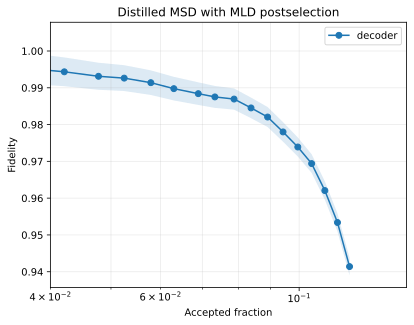

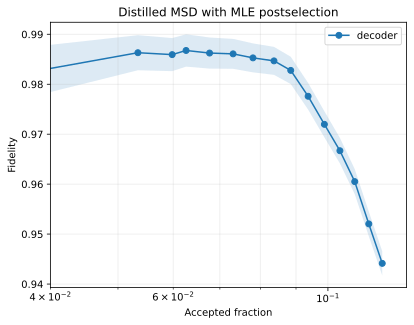

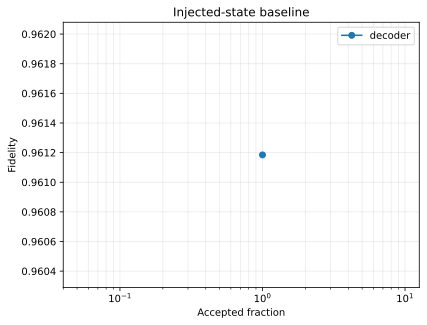

In [8]:
fig_mld, ax_mld = msd_mld_exp.analysis_visualization(
    min_accepted_fraction=0.04,
    title="Distilled MSD with MLD postselection",
)

if msd_mle_exp is not None:
    fig_mle, ax_mle = msd_mle_exp.analysis_visualization(
        min_accepted_fraction=0.04,
        title="Distilled MSD with MLE postselection",
    )

fig_injected, ax_injected = injected_mld_exp.analysis_visualization(
    min_accepted_fraction=0.04,
    title="Injected-state baseline",
)



## Combined figure



Plotting decoder curves...


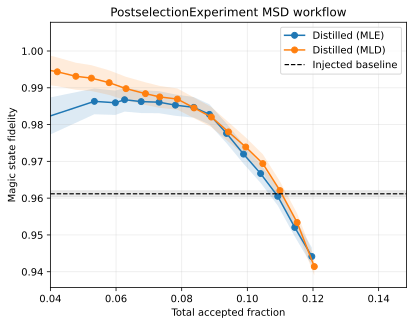

In [9]:
curves = {"Distilled (MLD)": msd_mld_curve}
if msd_mle_curve is not None:
    curves = {"Distilled (MLE)": msd_mle_curve, **curves}

fig, ax = plot_decoder_curves(
    curves,
    injected_summary=injected_summary,
    min_accepted_fraction=0.04,
    title="PostselectionExperiment MSD workflow",
)
ax.set_xscale("linear")
ax.set_xlabel("Total accepted fraction")
ax.set_ylabel("Magic state fidelity")
ax.legend()


# debug

In [10]:
import numpy as np

def summarize_curve(name, curve):
    print(f"\n{name}")
    print("keys:", curve.keys())

    for key in ["accepted_fraction", "fidelity", "credible", "low", "high", "median", "point", "error"]:
        if key not in curve:
            continue
        arr = np.asarray(curve[key])
        print(
            key,
            "shape=", arr.shape,
            "dtype=", arr.dtype,
            "min=", np.nanmin(arr) if arr.size else None,
            "max=", np.nanmax(arr) if arr.size else None,
        )

    credible = np.asarray(curve.get("credible", []), dtype=float)
    accepted = np.asarray(curve.get("accepted_fraction", []), dtype=float)
    fidelity = np.asarray(curve.get("fidelity", []), dtype=float)

    if credible.shape == (len(accepted), 2) and len(accepted):
        idx = int(np.nanargmin(credible[:, 0]))
        print("lowest credible interval row:")
        print("  idx:", idx)
        print("  accepted:", accepted[idx])
        print("  fidelity:", fidelity[idx])
        print("  low:", credible[idx, 0])
        print("  high:", credible[idx, 1])

summarize_curve("MLD", msd_mld_curve)

if msd_mle_curve is not None:
    summarize_curve("MLE", msd_mle_curve)

print("\ninjected_summary")
print(injected_summary)


MLD
keys: dict_keys(['accepted_fraction', 'fidelity', 'point_fidelity', 'credible'])
accepted_fraction shape= (19,) dtype= float64 min= 0.001823 max= 0.12039933333333333
fidelity shape= (19,) dtype= float64 min= 0.9413988419527832 max= 0.995100455214595
credible shape= (19, 2) dtype= float64 min= 0.9389725677530129 max= 1.0045394075543672
lowest credible interval row:
  idx: 18
  accepted: 0.12039933333333333
  fidelity: 0.9413988419527832
  low: 0.9389725677530129
  high: 0.9438251161525536

MLE
keys: dict_keys(['accepted_fraction', 'fidelity', 'point_fidelity', 'credible'])
accepted_fraction shape= (15,) dtype= float64 min= 0.024226 max= 0.119645
fidelity shape= (15,) dtype= float64 min= 0.9441403453818213 max= 0.9867613210104633
credible shape= (15, 2) dtype= float64 min= 0.9417117422012798 max= 0.9899972018760888
lowest credible interval row:
  idx: 14
  accepted: 0.119645
  fidelity: 0.9441403453818213
  low: 0.9417117422012798
  high: 0.9465689485623628

injected_summary
{'point

Plotting decoder curves...
ylim: (np.float64(0.9356942257629451), np.float64(1.007817749544435))
collection 0 y min/max: 0.9417117422012798 0.9899972018760888
collection 1 y min/max: 0.9389725677530129 1.0045394075543672
line 0 Distilled (MLE) y min/max: 0.9441403453818213 0.9867613210104633
line 1 Distilled (MLD) y min/max: 0.9413988419527832 0.995100455214595
line 2 Injected baseline y min/max: 0.9611845082773272 0.9611845082773272


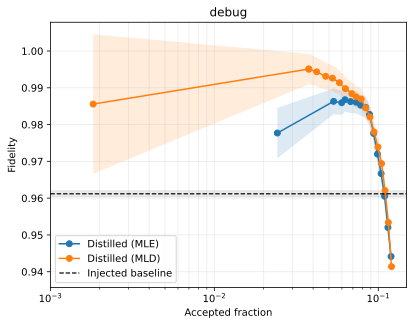

In [11]:
fig, ax = plot_decoder_curves(
    curves,
    injected_summary=injected_summary,
    min_accepted_fraction=0.001,
    title="debug",
)
print("ylim:", ax.get_ylim())

for i, collection in enumerate(ax.collections):
    try:
        paths = collection.get_paths()
        ys = np.concatenate([p.vertices[:, 1] for p in paths if len(p.vertices)])
        print("collection", i, "y min/max:", np.nanmin(ys), np.nanmax(ys))
    except Exception as exc:
        print("collection", i, "could not inspect:", exc)

for i, line in enumerate(ax.lines):
    y = np.asarray(line.get_ydata(), dtype=float)
    print("line", i, line.get_label(), "y min/max:", np.nanmin(y), np.nanmax(y))